# Plots

In [1]:
%matplotlib inline
from easyvvuq.analysis.sc_analysis import SCAnalysisResults

from typing import cast

from src import machines
from src import programs
from src import energyuq
from src.util import plot, parser
from src.util.data import *


import matplotlib.pyplot as plt

In [2]:
DAKOTA=True
EASY=True
result_set: dict[str, Result] = {}
qois = ["energy_uj", "time"]

if DAKOTA:
    result_set["dakota"] = Result(parser.parse_dakota_file("pce_samples.dat"), qois)

if EASY:
    campaign_name = "energy"
    campaign, analysis = energyuq.load(programs.FFT, machines.Glados, campaign_name)

    result_set["easyvvuq"] = EasyResult(
        campaign.get_collation_result(),
        qois,
        analysis,
        campaign,
        energyuq.get_sampler(campaign),
        cast(SCAnalysisResults, campaign.get_last_analysis())
    )



## Which configurations consumed less energy or time in total

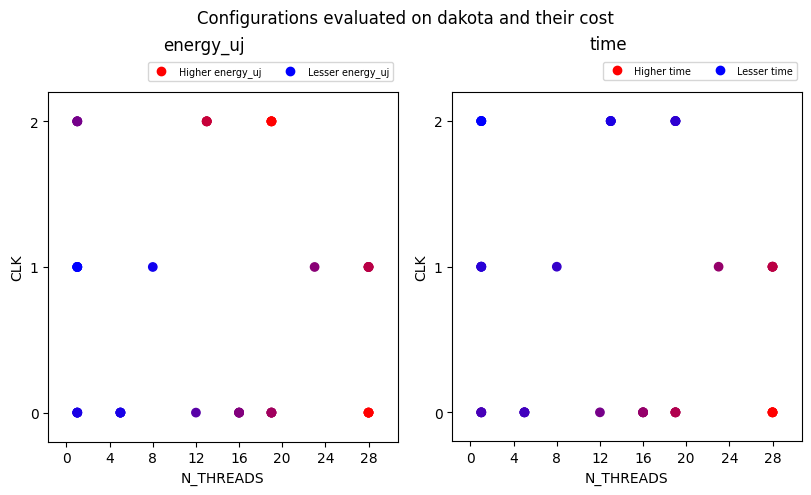

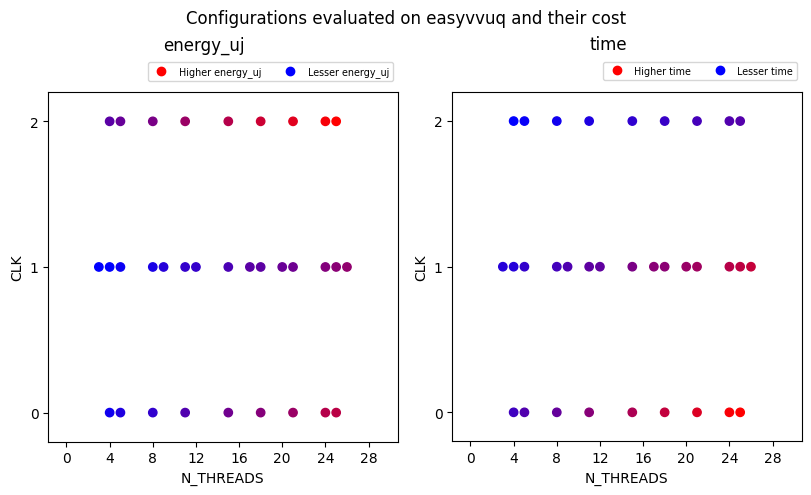

In [3]:
for name, result in result_set.items():
    fig = plt.figure(figsize=(8,8), layout="constrained")
    fig.suptitle(f"Configurations evaluated on {name} and their cost")
    fs = fig.subfigures(1, 2)
    c=0
    for qoi in qois:
        f = plot.plot_grid_2D_best(result, qoi, subfig=fs[c])
        f.suptitle(qoi)
        c += 1


## What is the difference between the best and worst configurations?

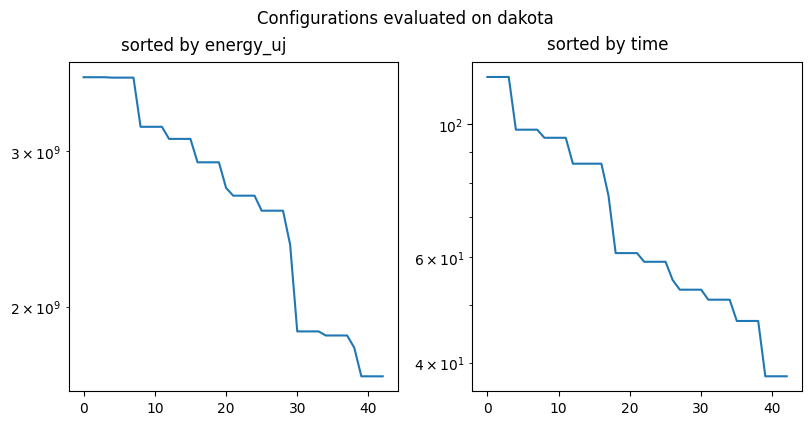

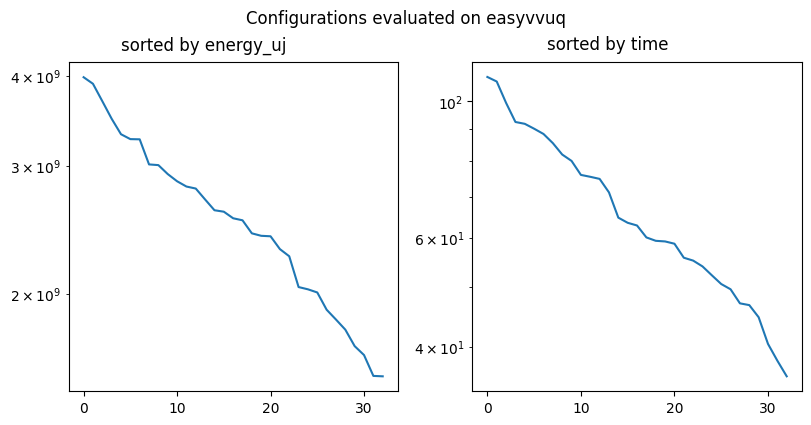

In [ ]:
for name, result in result_set.items():
    fig = plt.figure(figsize=(8,8), layout="constrained")
    fig.suptitle(f"Configurations evaluated on {name}")
    fs = fig.subfigures(1, 2) #could be more that 2
    c=0
    for qoi in qois:
        if qoi not in result.qois:
            continue
        f = plot.plot_sorted(result, qoi, subfig=fs[c])
        f.suptitle(f'sorted by {qoi}')
        c+=1

## View of the resulting energy usage and time against each parameter

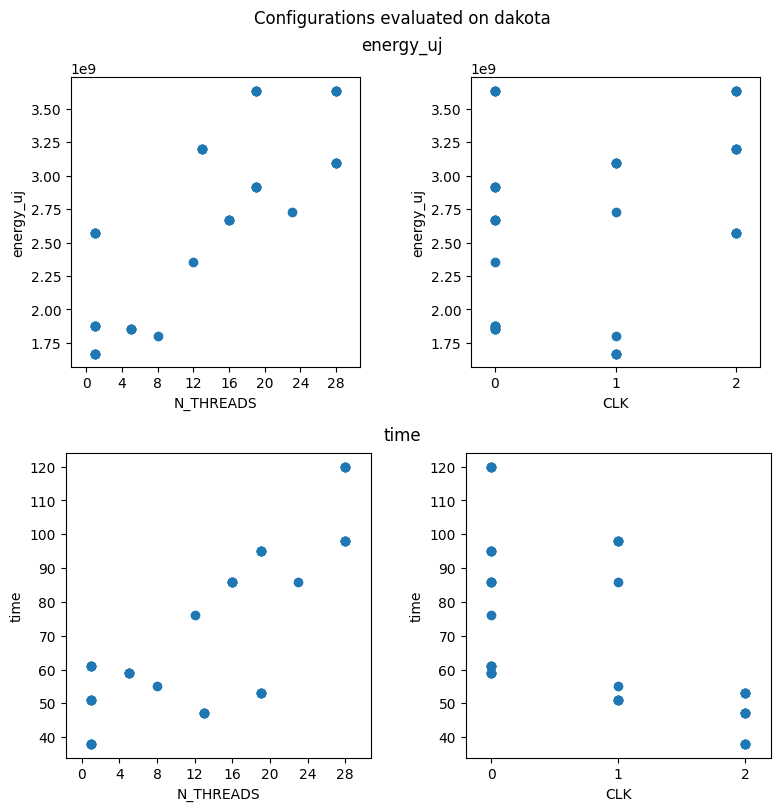

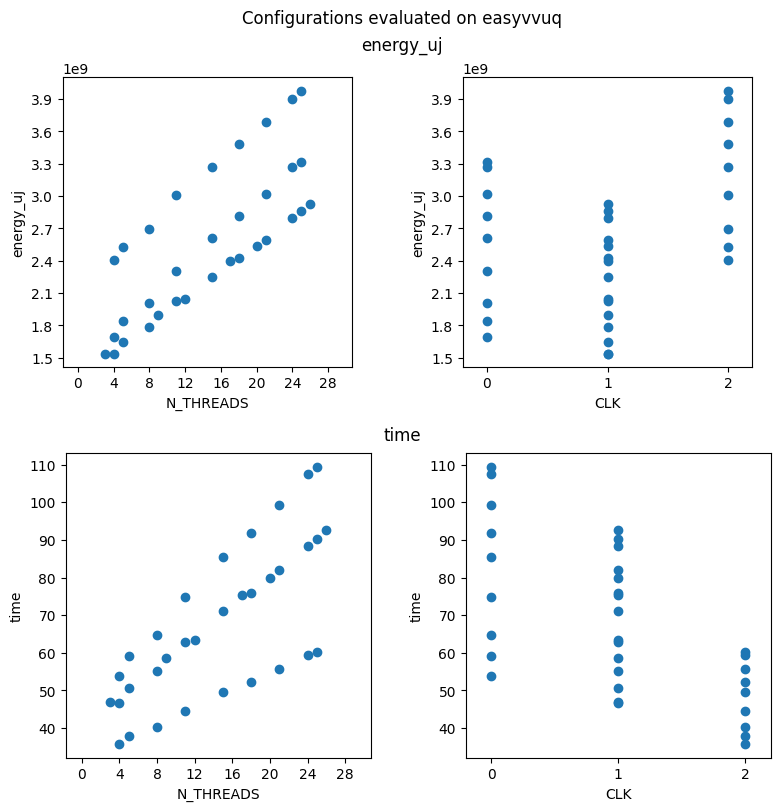

In [ ]:

for name, result in result_set.items():
    fig = plt.figure(figsize=(8,8), layout="constrained")
    fig.suptitle(f"Configurations evaluated on {name}")
    fs = fig.subfigures(2, 1) #could be more that 2
    c=0
    for qoi in qois:
        if qoi not in result.qois:
            continue
        f = plot.plot_2D_single_dimension(result, qoi, subfig=fs[c])
        f.suptitle(qoi)
        c+=1
    fig.align_titles()

# EasyVVUQ plots
The following could be generated only from easyvvuq, for now

## First order sobol indices and decomposition treemap

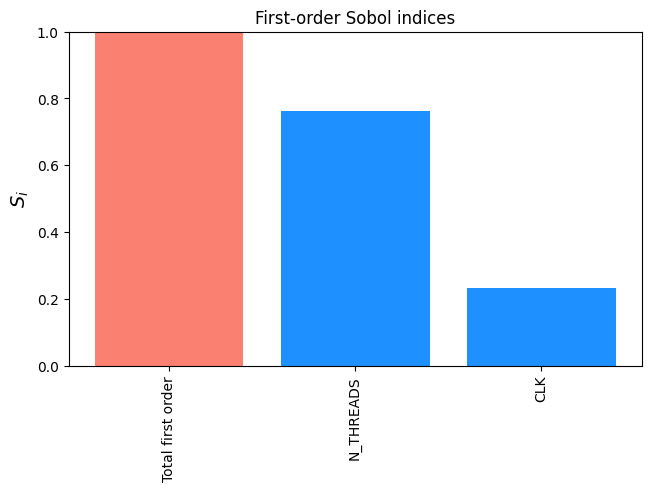

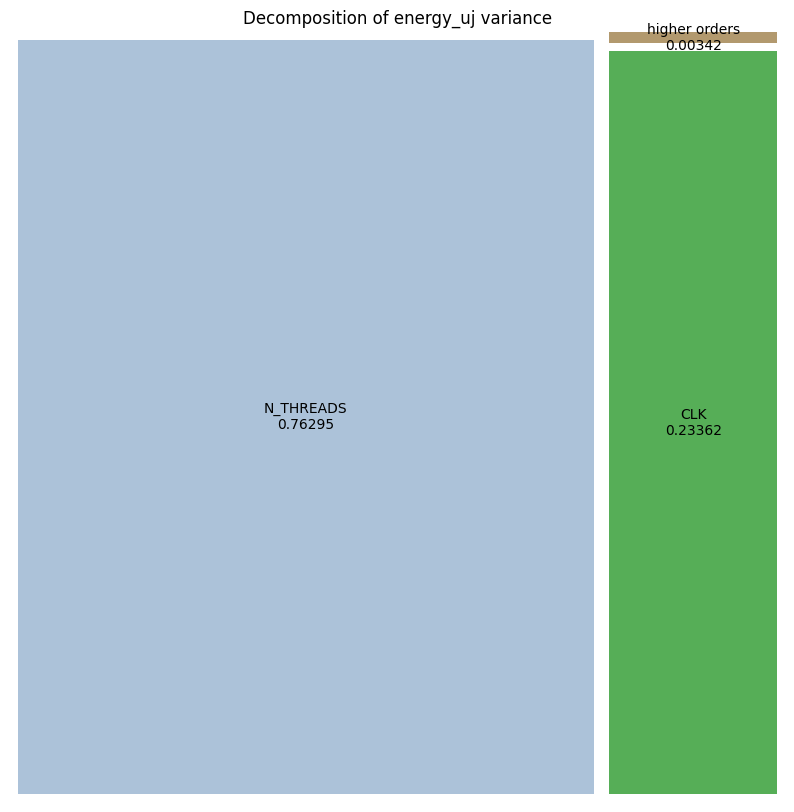

In [ ]:

for name, result in result_set.items():
    if not isinstance(result, EasyResult):
        continue
    plot.plot_sobols1(result, "energy_uj")
    result.results.plot_sobols_treemap("energy_uj", figsize=(10, 10))
    plt.axis('off')

## Adaptation table, histogram and errors

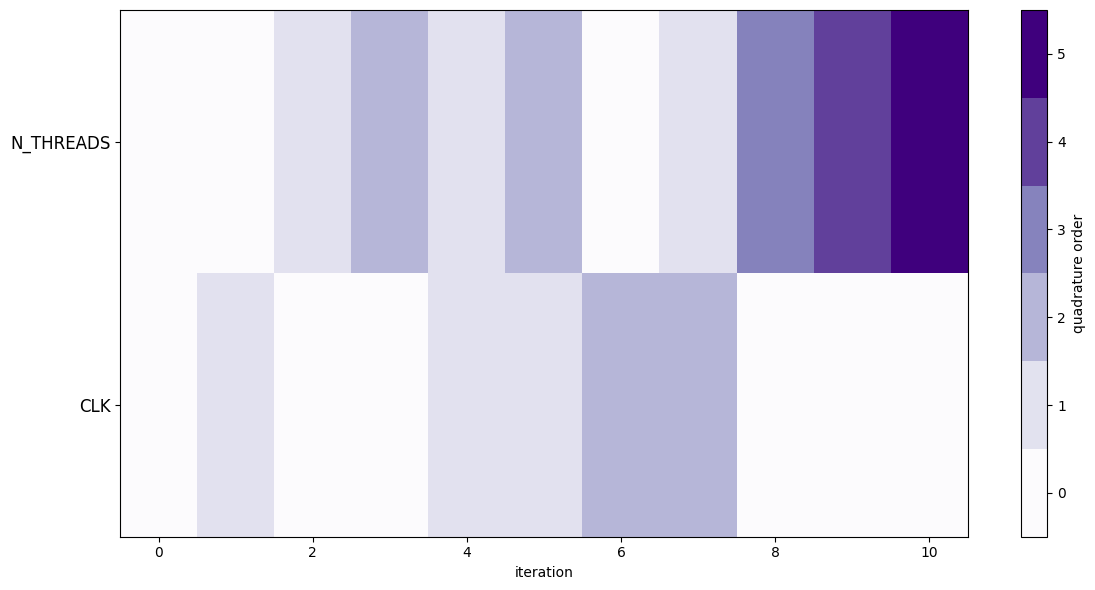

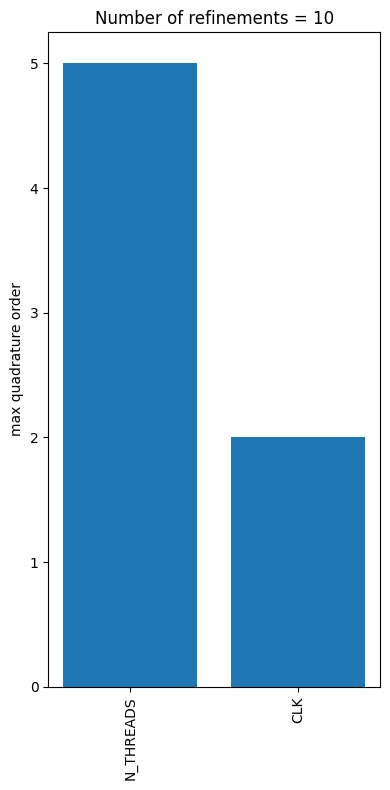

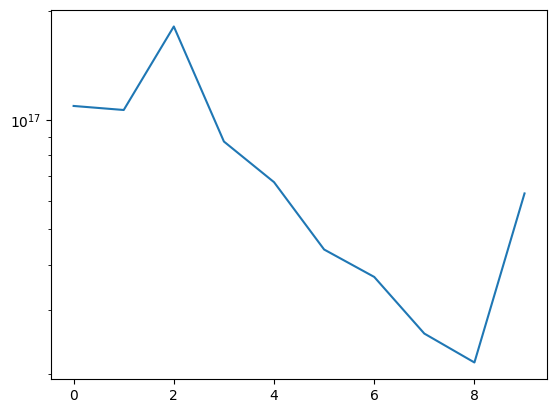

In [ ]:
for name, result in result_set.items():
    if not isinstance(result, EasyResult):
        continue
    result.analysis.adaptation_table()
    result.analysis.adaptation_histogram()
    plt.semilogy(result.analysis.get_adaptation_errors())

## Uncertainty amplification and stat convergence

-----------------
Mean CV input = 68.6791 %
Mean CV output = 26.7429 %
Uncertainty amplification factor = 0.2674/0.6868 = 0.3894
-----------------


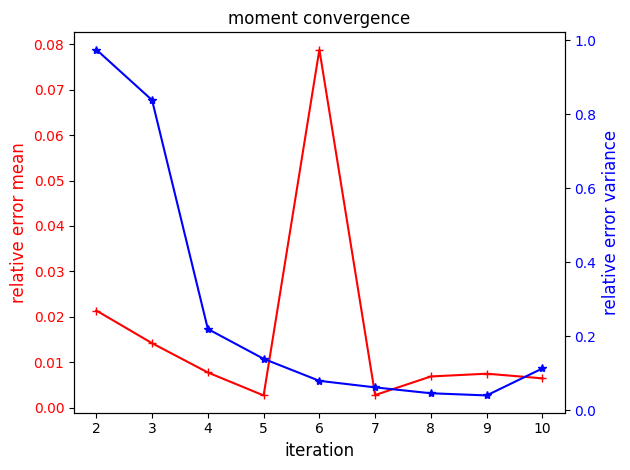

In [ ]:
for name, result in result_set.items():
    if not isinstance(result, EasyResult):
        continue
    result.analysis.get_uncertainty_amplification("energy_uj")
    result.analysis.plot_stat_convergence()